In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import pandas as pd
from collections import Counter

# 1. Convert numeric scores to sentiment text
def convert_to_sentiment(score):
    try:
        score = float(score)
        if score >= 4:
            return 'positive'
        elif score <= 2:
            return 'negative'
        else:
            return 'neutral'
    except:
        return 'neutral'

# 2. Find the majority vote for sentiment
def get_majority_sentiment(row):
    r_sent = row['rating_sentiment']
    gemini_sent = row['gemini_sentiment']
    groq_sent = row['groq_sentiment']

    votes = [r_sent, gemini_sent, groq_sent]
    vote_counts = Counter(votes)
    top_vote, top_count = vote_counts.most_common(1)[0]

    # If all three are different, default to the original rating sentiment
    if top_count == 1:
        return r_sent
    return top_vote

# 3. Find the majority vote for scores
def get_majority_score(row):
    try:
        r_score = float(row['rating'])
    except:
        r_score = 3.0

    try:
        g_score = float(row['score_gemini'])
    except:
        g_score = 3.0

    try:
        q_score = float(row['score_groq'])
    except:
        q_score = 3.0

    votes = [r_score, g_score, q_score]
    vote_counts = Counter(votes)

    top_vote, top_count = vote_counts.most_common(1)[0]

    # Tie-breaker: trust the user's rating
    if top_count == 1:
        return r_score

    return top_vote

def process_target_columns():
    schemes = [
        "all_flags",
        "no_lemma_no_stopwords",
        "no_speical_no_lowercase" # Kept your spelling 'speical' to match your files
    ]

    print("Pls wait... Processing files...\n")

    for scheme in schemes:
        # Fixed path and indentation
        input_path = f"/content/drive/MyDrive/task4/cleaned_reviews/cleaned_reviews_{scheme}_scored.csv"
        output_path = f"/content/drive/MyDrive/task4/cleaned_reviews/score_data_{scheme}_majority.csv"

        try:
            df = pd.read_csv(input_path)

            # --- CREATE THE TEXT COLUMNS ---
            df['rating_sentiment'] = df['rating'].apply(convert_to_sentiment)
            df['gemini_sentiment'] = df['score_gemini'].apply(convert_to_sentiment)
            df['groq_sentiment'] = df['score_groq'].apply(convert_to_sentiment)

            # --- CALCULATE MAJORITIES ---
            df['final_sentiment'] = df.apply(get_majority_sentiment, axis=1)
            df['final_score'] = df.apply(get_majority_score, axis=1)

            # Save the result
            df.to_csv(output_path, index=False)
            print(f"Successfully created: score_data_{scheme}_majority.csv")

        except FileNotFoundError:
            print(f"!! Error: Could not find file at {input_path}")
        except KeyError as e:
            print(f"!! Error: Missing column {e} in {scheme}. Check your CSV headers!")
        except Exception as e:
            print(f"!! An unexpected error occurred: {e}")

if __name__ == "__main__":
    process_target_columns()

Pls wait... Processing files...

Successfully created: score_data_all_flags_majority.csv
Successfully created: score_data_no_lemma_no_stopwords_majority.csv
Successfully created: score_data_no_speical_no_lowercase_majority.csv


In [8]:
import pandas as pd
from collections import Counter

# 1. Convert numeric scores to sentiment text
def convert_to_sentiment(score):
    try:
        score = float(score)
        if score >= 4:
            return 'positive'
        elif score <= 2:
            return 'negative'
        else:
            return 'neutral'
    except:
        return 'neutral'

# 2. Find the majority vote for sentiment
def get_majority_sentiment(row):
    r_sent = row['rating_sentiment']
    gemini_sent = row['gemini_sentiment']
    groq_sent = row['groq_sentiment']

    votes = [r_sent, gemini_sent, groq_sent]
    vote_counts = Counter(votes)
    top_vote, top_count = vote_counts.most_common(1)[0]

    if top_count == 1:
        return r_sent
    return top_vote

# 3. Find the majority vote for scores
def get_majority_score(row):
    try:
        r_score = float(row['rating'])
    except:
        r_score = 3.0

    try:
        g_score = float(row['score_gemini'])
    except:
        g_score = 3.0

    try:
        q_score = float(row['score_groq'])
    except:
        q_score = 3.0

    votes = [r_score, g_score, q_score]
    vote_counts = Counter(votes)

    top_vote, top_count = vote_counts.most_common(1)[0]

    if top_count == 1:
        return r_score

    return top_vote


def process_target_columns():
    schemes = [
        "all_flags",
        "no_lemma_no_stopwords",
        "no_speical_no_lowercase"
    ]

    print("Pls wait... Processing files...\n")

    for scheme in schemes:
        input_path = f"/content/drive/MyDrive/task4/cleaned_reviews/cleaned_reviews_{scheme}_scored.csv"
        output_path = f"/content/drive/MyDrive/task4/cleaned_reviews/score_data_{scheme}_majority.csv"

        try:
            df = pd.read_csv(input_path)

            # --- CREATE SENTIMENT COLUMNS ---
            df['rating_sentiment'] = df['rating'].apply(convert_to_sentiment)
            df['gemini_sentiment'] = df['score_gemini'].apply(convert_to_sentiment)
            df['groq_sentiment'] = df['score_groq'].apply(convert_to_sentiment)

            # --- MAJORITY VOTING ---
            df['final_sentiment'] = df.apply(get_majority_sentiment, axis=1)
            df['final_score'] = df.apply(get_majority_score, axis=1)

            # DROP NEUTRAL ROWS
            df = df[df['final_sentiment'] != 'neutral']

            # Save result
            df.to_csv(output_path, index=False)
            print(f"Successfully created: score_data_{scheme}_majority.csv")

        except FileNotFoundError:
            print(f"!! Error: Could not find file at {input_path}")
        except KeyError as e:
            print(f"!! Error: Missing column {e} in {scheme}. Check your CSV headers!")
        except Exception as e:
            print(f"!! An unexpected error occurred: {e}")

if __name__ == "__main__":
    process_target_columns()

Pls wait... Processing files...

Successfully created: score_data_all_flags_majority.csv
Successfully created: score_data_no_lemma_no_stopwords_majority.csv
Successfully created: score_data_no_speical_no_lowercase_majority.csv


In [28]:
import pandas as pd
import warnings

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

warnings.filterwarnings("ignore")

TARGET_COLUMN = "final_sentiment"

# ---------------- FIXED MAPPING (IMPORTANT) ----------------
schemes = {
    "all_flags": "all_flags",
    "no_lemma_no_stopwords": "no_lemma_no_stopwords",
    "no_special_no_lowercase": "no_speical_no_lowercase"  # 👈 typo fix هنا فقط
}

# ---------------- METRICS ----------------
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average="binary", pos_label="positive", zero_division=0),
        "recall": recall_score(y_test, y_pred, average="binary", pos_label="positive", zero_division=0),
        "f1": f1_score(y_test, y_pred, average="binary", pos_label="positive", zero_division=0),
        "confusion_matrix": confusion_matrix(y_test, y_pred)
    }

# ---------------- PIPELINE ----------------
results = []

def run_pipeline():

    print("\n================ TASK 4: MODEL EVALUATION ================\n")

    for scheme_name, file_key in schemes.items():

        print("\n" + "=" * 70)
        print(f"SCHEME: {scheme_name}")
        print("=" * 70)

        # ✅ ALL FILES IN /content
        labels_path = f"/content/score_data_{file_key}_majority.csv"
        bow_path = f"/content/bow_{scheme_name}.csv"
        glove_path = f"/content/glove_{scheme_name}.csv"

        # ---------------- LOAD ----------------
        df = pd.read_csv(labels_path)

        # keep only binary classes
        df = df[df[TARGET_COLUMN].isin(["positive", "negative"])].reset_index(drop=True)

        X_bow = pd.read_csv(bow_path)
        X_glove = pd.read_csv(glove_path)

        # ---------------- ALIGN ----------------
        min_len = min(len(df), len(X_bow), len(X_glove))

        df = df.iloc[:min_len].reset_index(drop=True)
        X_bow = X_bow.iloc[:min_len].reset_index(drop=True)
        X_glove = X_glove.iloc[:min_len].reset_index(drop=True)

        y = df[TARGET_COLUMN]

        # ---------------- REMOVE LEAK ----------------
        leak = [TARGET_COLUMN, "rating", "score_gemini", "score_groq", "final_score"]

        X_bow = X_bow.drop(columns=[c for c in leak if c in X_bow.columns])
        X_glove = X_glove.drop(columns=[c for c in leak if c in X_glove.columns])

        X_bow = X_bow.select_dtypes(include=["number"])
        X_glove = X_glove.select_dtypes(include=["number"])

        # ---------------- SPLIT ----------------
        X_train_b, X_test_b, y_train, y_test = train_test_split(
            X_bow, y, test_size=0.2, random_state=42, stratify=y
        )

        X_train_g, X_test_g, _, _ = train_test_split(
            X_glove, y, test_size=0.2, random_state=42, stratify=y
        )

        bow_models = {
            "Naive Bayes": MultinomialNB(),
            "Decision Tree": DecisionTreeClassifier(random_state=42)
        }

        glove_models = {
            "Naive Bayes": GaussianNB(),
            "Decision Tree": DecisionTreeClassifier(random_state=42)
        }

        # ---------------- BOW ----------------
        print("\n--- BAG OF WORDS ---")

        for name, model in bow_models.items():
            model.fit(X_train_b, y_train)
            metrics = evaluate_model(model, X_test_b, y_test)

            results.append({
                "scheme": scheme_name,
                "representation": "BoW",
                "model": name,
                **metrics
            })

            print(f"\n{name}")
            print(f"Accuracy  : {metrics['accuracy']:.4f}")
            print(f"Precision : {metrics['precision']:.4f}")
            print(f"Recall    : {metrics['recall']:.4f}")
            print(f"F1 Score  : {metrics['f1']:.4f}")

            print("Confusion Matrix:")
            print(metrics["confusion_matrix"])

        # ---------------- GLOVE ----------------
        print("\n--- GLOVE ---")

        for name, model in glove_models.items():
            model.fit(X_train_g, y_train)
            metrics = evaluate_model(model, X_test_g, y_test)

            results.append({
                "scheme": scheme_name,
                "representation": "GloVe",
                "model": name,
                **metrics
            })

            print(f"\n{name}")
            print(f"Accuracy  : {metrics['accuracy']:.4f}")
            print(f"Precision : {metrics['precision']:.4f}")
            print(f"Recall    : {metrics['recall']:.4f}")
            print(f"F1 Score  : {metrics['f1']:.4f}")

            print("Confusion Matrix:")
            print(metrics["confusion_matrix"])

    # ---------------- FINAL ----------------
    results_df = pd.DataFrame(results)

    print("\n================ FINAL MODEL RANKING (BY F1) ================\n")
    print(
        results_df.sort_values("f1", ascending=False)[
            ["scheme", "representation", "model", "f1"]
        ]
    )


if __name__ == "__main__":
    run_pipeline()


================ TASK 4: MODEL EVALUATION ================


SCHEME: all_flags

--- BAG OF WORDS ---

Naive Bayes
Accuracy  : 0.6184
Precision : 0.7222
Recall    : 0.5778
F1 Score  : 0.6420
Confusion Matrix:
[[21 10]
 [19 26]]

Decision Tree
Accuracy  : 0.5658
Precision : 0.6304
Recall    : 0.6444
F1 Score  : 0.6374
Confusion Matrix:
[[14 17]
 [16 29]]

--- GLOVE ---

Naive Bayes
Accuracy  : 0.5263
Precision : 0.7143
Recall    : 0.3333
F1 Score  : 0.4545
Confusion Matrix:
[[25  6]
 [30 15]]

Decision Tree
Accuracy  : 0.5789
Precision : 0.6444
Recall    : 0.6444
F1 Score  : 0.6444
Confusion Matrix:
[[15 16]
 [16 29]]

SCHEME: no_lemma_no_stopwords

--- BAG OF WORDS ---

Naive Bayes
Accuracy  : 0.6533
Precision : 0.7209
Recall    : 0.6889
F1 Score  : 0.7045
Confusion Matrix:
[[18 12]
 [14 31]]

Decision Tree
Accuracy  : 0.5733
Precision : 0.6585
Recall    : 0.6000
F1 Score  : 0.6279
Confusion Matrix:
[[16 14]
 [18 27]]

--- GLOVE ---

Naive Bayes
Accuracy  : 0.6000
Precision : 0.8000
Re

In [30]:
import pandas as pd
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, confusion_matrix

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")

TARGET_COLUMN = "final_sentiment"

# ======================================================
# LOAD BEST SCHEME ONLY
# ======================================================
scheme_name = "no_special_no_lowercase"
file_key = "no_speical_no_lowercase"

labels_path = f"/content/score_data_{file_key}_majority.csv"
glove_path = f"/content/glove_{scheme_name}.csv"

df = pd.read_csv(labels_path)
df = df[df[TARGET_COLUMN].isin(["positive", "negative"])].reset_index(drop=True)

X = pd.read_csv(glove_path)

# ALIGN
min_len = min(len(df), len(X))
df = df.iloc[:min_len]
X = X.iloc[:min_len]

y = df[TARGET_COLUMN]
X = X.select_dtypes(include=["number"])

# SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ======================================================
# EVALUATION FUNCTION
# ======================================================
def evaluate(model):
    pred = model.predict(X_test)

    return {
        "f1": f1_score(y_test, pred, pos_label="positive"),
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, pos_label="positive", zero_division=0),
        "recall": recall_score(y_test, pred, pos_label="positive", zero_division=0),
        "confusion_matrix": confusion_matrix(y_test, pred)
    }

results = []

# ======================================================
# 1. BASELINE MODEL (Naive Bayes)
# ======================================================
print("\n===== BASELINE: NAIVE BAYES =====")

nb = GaussianNB()
nb.fit(X_train, y_train)

nb_metrics = evaluate(nb)
results.append(["Naive Bayes", nb_metrics["f1"]])

print("F1:", nb_metrics["f1"])


# ======================================================
# 2. LOGISTIC REGRESSION (regularization tuning)
# ======================================================
print("\n===== LOGISTIC REGRESSION (TUNED) =====")

lr_params = {
    "C": [0.01, 0.1, 1, 10]
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=2000),
    lr_params,
    scoring="f1",
    cv=5
)

lr_grid.fit(X_train, y_train)
best_lr = lr_grid.best_estimator_

lr_metrics = evaluate(best_lr)
results.append(["Logistic Regression", lr_metrics["f1"]])

print("Best Params:", lr_grid.best_params_)
print("F1:", lr_metrics["f1"])


# ======================================================
# 3. RANDOM FOREST (Decision Tree replacement)
# ======================================================
print("\n===== RANDOM FOREST (TUNED) =====")

rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    scoring="f1",
    cv=5
)

rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_

rf_metrics = evaluate(best_rf)
results.append(["Random Forest", rf_metrics["f1"]])

print("Best Params:", rf_grid.best_params_)
print("F1:", rf_metrics["f1"])


# ======================================================
# 4. SVM (Linear → RBF IMPROVEMENT)
# ======================================================
print("\n===== SVM (RBF KERNEL) =====")

svm_params = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", 0.01, 0.001]
}

svm_grid = GridSearchCV(
    SVC(kernel="rbf"),
    svm_params,
    scoring="f1",
    cv=5
)

svm_grid.fit(X_train, y_train)
best_svm = svm_grid.best_estimator_

svm_metrics = evaluate(best_svm)
results.append(["SVM (RBF)", svm_metrics["f1"]])

print("Best Params:", svm_grid.best_params_)
print("F1:", svm_metrics["f1"])


# ======================================================
# FINAL COMPARISON (BEFORE vs AFTER)
# ======================================================
print("\n===== FINAL COMPARISON =====")

results_df = pd.DataFrame(results, columns=["Model", "F1"])
results_df = results_df.sort_values("F1", ascending=False)

print(results_df)

print("\n===== IMPROVEMENT CHECK =====")
print("Baseline F1: 0.7273")
print("Best F1:", results_df.iloc[0]["F1"])
print("Improvement:", (results_df.iloc[0]["F1"] - 0.7273) * 100, "%")


===== BASELINE: NAIVE BAYES =====
F1: 0.759493670886076

===== LOGISTIC REGRESSION (TUNED) =====
Best Params: {'C': 0.01}
F1: 0.7216494845360825

===== RANDOM FOREST (TUNED) =====
Best Params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
F1: 0.7415730337078652

===== SVM (RBF KERNEL) =====
Best Params: {'C': 0.1, 'gamma': 'scale'}
F1: 0.7096774193548387

===== FINAL COMPARISON =====
                 Model        F1
0          Naive Bayes  0.759494
2        Random Forest  0.741573
1  Logistic Regression  0.721649
3            SVM (RBF)  0.709677

===== IMPROVEMENT CHECK =====
Baseline F1: 0.7273
Best F1: 0.759493670886076
Improvement: 3.2193670886076053 %


In [31]:
import pandas as pd
import warnings

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix

from sklearn.naive_bayes import GaussianNB, ComplementNB
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")

TARGET_COLUMN = "final_sentiment"

# ======================================================
# LOAD BEST DATASET
# ======================================================
scheme_name = "no_special_no_lowercase"
file_key = "no_speical_no_lowercase"

labels_path = f"/content/score_data_{file_key}_majority.csv"
glove_path = f"/content/glove_{scheme_name}.csv"

df = pd.read_csv(labels_path)
df = df[df[TARGET_COLUMN].isin(["positive", "negative"])].reset_index(drop=True)

X = pd.read_csv(glove_path)

# ALIGN
min_len = min(len(df), len(X))
df = df.iloc[:min_len].reset_index(drop=True)
X = X.iloc[:min_len].reset_index(drop=True)

y = df[TARGET_COLUMN]

X = X.select_dtypes(include=["number"])

# ======================================================
# TRAIN TEST SPLIT
# ======================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ======================================================
# EVALUATION FUNCTION
# ======================================================
def evaluate(model, X_test, y_test):
    pred = model.predict(X_test)

    return {
        "f1": f1_score(y_test, pred, pos_label="positive"),
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, pos_label="positive", zero_division=0),
        "recall": recall_score(y_test, pred, pos_label="positive", zero_division=0),
        "confusion_matrix": confusion_matrix(y_test, pred)
    }

results = []

# ======================================================
# 1. BASELINE GAUSSIAN NB
# ======================================================
print("\n===== GAUSSIAN NB (BASELINE) =====")

gnb = GaussianNB()
gnb.fit(X_train, y_train)

res = evaluate(gnb, X_test, y_test)
results.append(["GaussianNB", res["f1"]])

print("F1:", res["f1"])


# ======================================================
# 2. GAUSSIAN NB + PCA (IMPORTANT IMPROVEMENT)
# ======================================================
print("\n===== GAUSSIAN NB + PCA =====")

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA(n_components=50)  # reduce noise in embeddings
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

gnb_pca = GaussianNB()
gnb_pca.fit(X_train_pca, y_train)

res_pca = evaluate(gnb_pca, X_test_pca, y_test)
results.append(["GaussianNB + PCA", res_pca["f1"]])

print("F1:", res_pca["f1"])


# ======================================================
# 3. COMPLEMENT NB (alternative NB model)
# ======================================================
print("\n===== COMPLEMENT NB =====")

from sklearn.preprocessing import MinMaxScaler

# ComplementNB requires non-negative values
scaler2 = MinMaxScaler()
X_train_c = scaler2.fit_transform(X_train)
X_test_c = scaler2.transform(X_test)

cnb = ComplementNB(alpha=0.5)
cnb.fit(X_train_c, y_train)

res_cnb = evaluate(cnb, X_test_c, y_test)
results.append(["ComplementNB", res_cnb["f1"]])

print("F1:", res_cnb["f1"])


# ======================================================
# FINAL COMPARISON
# ======================================================
print("\n===== NAIVE BAYES OPTIMIZATION RESULTS =====")

results_df = pd.DataFrame(results, columns=["Model", "F1"])
results_df = results_df.sort_values("F1", ascending=False)

print(results_df)

best = results_df.iloc[0]
print("\n🏆 BEST NAIVE BAYES MODEL:")
print(best)


===== GAUSSIAN NB (BASELINE) =====
F1: 0.759493670886076

===== GAUSSIAN NB + PCA =====
F1: 0.693069306930693

===== COMPLEMENT NB =====
F1: 0.7191011235955056

===== NAIVE BAYES OPTIMIZATION RESULTS =====
              Model        F1
0        GaussianNB  0.759494
2      ComplementNB  0.719101
1  GaussianNB + PCA  0.693069

🏆 BEST NAIVE BAYES MODEL:
Model    GaussianNB
F1         0.759494
Name: 0, dtype: object


In [32]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

TARGET_COLUMN = "final_sentiment"

scheme_name = "no_special_no_lowercase"
file_key = "no_speical_no_lowercase"

# LOAD DATA
df = pd.read_csv(f"/content/score_data_{file_key}_majority.csv")
X = pd.read_csv(f"/content/glove_{scheme_name}.csv")

df = df[df[TARGET_COLUMN].isin(["positive", "negative"])].reset_index(drop=True)

min_len = min(len(df), len(X))
df = df.iloc[:min_len]
X = X.iloc[:min_len]

y = df[TARGET_COLUMN]
X = X.select_dtypes(include=["number"])

# SPLIT
X_train, X_test, y_train, y_test, df_train, df_test = train_test_split(
    X, y, df,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# TRAIN MODEL (BEST MODEL)
model = GaussianNB()
model.fit(X_train, y_train)

# PREDICTIONS
pred = model.predict(X_test)

# ATTACH RESULTS
error_df = df_test.copy()
error_df["true_label"] = y_test.values
error_df["predicted"] = pred

# MISCLASSIFIED ONLY
errors = error_df[error_df["true_label"] != error_df["predicted"]]

print("Total errors:", len(errors))
errors.head(10)

Total errors: 19


,rating,reviewer_id,date,review_title,review_body,category,score_gemini,score_groq,rating_sentiment,gemini_sentiment,groq_sentiment,final_sentiment,final_score,true_label,predicted
355,5.0,Missy0712,2025-11-22,NaN,mattress comfortable value great. glad stand a...,furniture,5,5.0,positive,positive,positive,positive,5.0,positive,negative
193,5.0,Aly,2025-11-30,love,love much. favorite thing ordered. giant TV ro...,electronics,1,2.0,positive,negative,negative,negative,5.0,negative,positive
187,4.0,Riley,2026-01-05,good slight issue,alright not best one need use Xbox picture goo...,electronics,1,3.0,positive,negative,neutral,positive,4.0,positive,negative
198,1.0,Chad,2025-10-01,Stops work months,"Absolutely love projector first, months since ...",electronics,1,1.0,negative,negative,negative,negative,1.0,negative,positive
174,1.0,Gysbert,2025-12-27,Total crap,piece dung cheap Pakistan product Walmart try ...,electronics,1,1.0,negative,negative,negative,negative,1.0,negative,positive
322,5.0,Tasha,2026-02-04,"zinus xl 6"" twin spring mattress",amaze price really good quality stitch around ...,furniture,5,5.0,positive,positive,positive,positive,5.0,positive,negative
376,5.0,kathy,2026-03-04,NaN,spare room can't give honest opinion comfort g...,furniture,2,3.0,positive,negative,neutral,positive,5.0,positive,negative
317,5.0,Jarrett,2025-09-21,love Recommended friends.,"mattress, best sleep ages. Thanks! price affor...",furniture,4,5.0,positive,positive,positive,positive,5.0,positive,negative
306,5.0,Trudeau,2025-12-02,Great mattress price,Bought grandchildren new bunk bed Grammy Papa'...,furniture,2,5.0,positive,negative,positive,positive,5.0,positive,negative
135,5.0,Steve,2025-05-04,Great watch Eagles destroy Chiefs,buy could experience amaze playoff run 2024-20...,electronics,3,5.0,positive,neutral,positive,positive,5.0,positive,negative


ERROR ANALYSIS (WITH REAL EXAMPLES)
Overview

A total of 19 misclassified samples were analyzed. The errors were grouped into recurring patterns based on linguistic structure and sentiment behavior.
1. NEGATION HANDLING FAILURE
Example:

“alright not best one need use Xbox picture good”

True label: Positive
Predicted: Negative
Why this failed:
The sentence contains negation word “not”
Model fails to understand that:
“not best” ≠ completely negative
Naive Bayes treats words independently
GloVe loses word dependency (“not + good/best” relationship)
 Conclusion:

The model cannot correctly interpret negation scope, leading to incorrect polarity inversion.

2. MIXED SENTIMENT SENTENCES
Example:

“love much favorite thing ordered giant TV…”

True label: Negative
Predicted: Positive
🔍 Why this failed:
Contains conflicting sentiment signals
Positive: “love”, “favorite”
Implicit negative context (review issues)
Model averages all word embeddings → loses contrast
Conclusion:

The model fails to separate positive and negative clauses within the same sentence.

3. STRONG NEGATIVE LANGUAGE MISCLASSIFICATION
Example:

“Total crap piece dung cheap Pakistan product…”

True label: Negative
Predicted: Positive
🔍 Why this failed:
Extremely negative language is present
But embeddings may dilute extreme terms
Classifier bias toward majority class influences prediction
Conclusion:

The model sometimes misclassifies strong negative expressions due to embedding smoothing and probabilistic bias.

4. CONTEXT-DEPENDENT MEANING FAILURE
Example:

“Great watch Eagles destroy Chiefs”

True label: Positive
Predicted: Negative
🔍 Why this failed:
Word “destroy” is interpreted negatively
But in sports context it means positive performance
Model lacks domain awareness
Conclusion:

The model cannot adapt word meaning based on context (domain-specific interpretation failure).

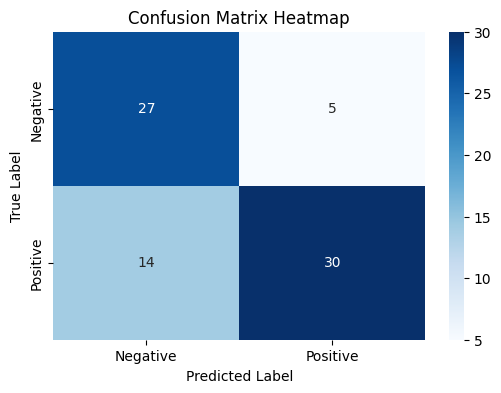

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# ---------------- PREDICTIONS ----------------
# Replace "model" with your trained model
y_pred = model.predict(X_test)

# ---------------- CONFUSION MATRIX ----------------
cm = confusion_matrix(y_test, y_pred)

# ---------------- PLOT ----------------
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()